# Diagnostic Notebook 1: CAF Branch Comparison

**Author:** S Dey | **Last updated:** May 2026

---

## Purpose

This notebook compares the CAF branch inventories of two or more icaruscode versions.
It answers the question: **which CAF branches were added, removed, or renamed between versions?**

Run this **before starting a new port** to understand the scope of CAF filling changes
needed in `sbncode`, and to check whether any existing analysis variables were removed or renamed.

## Generalisation

This notebook is written for the specific case of porting NuGraph2 from
`v10_06_00_01p01` (1D deconvolution, without NuGraph) to `v10_06_00_04p04` (2D deconvolution, with NuGraph).
The example input files reflect this port. However, the notebook is fully general:
point it at any two (or more) flat CAF ROOT files from different icaruscode versions
and it will produce the same comparison.

## What You Get

- Branch inventory per file (tree-qualified and plain names)
- Pairwise Jaccard similarity matrices and heatmaps
- Pairwise difference CSVs: `only_in_A`, `only_in_B`, `common`
- Presence/absence matrix across all versions
- Tree-level breakdown
- Prefix-grouped summary of branches unique to each version

## Reference Output (v01p01 vs v04p04)

| Comparison | Branches in A | Branches in B | Only in A | Only in B | Jaccard |
|---|---|---|---|---|---|
| v01p01 vs v04p04 | 2057 | 2106 | 0 | 49 | 0.977 |

**Key finding:** `n_only_A = 0` — no CAF branch was removed or renamed.
All 49 new branches in v04p04 are pure additions.
The NuGraph CAF filling code required no variable name changes.

> If you see `n_only_A > 0` in your port, those branches were removed or renamed and
> will need updating in `sbncode/CAFMaker/FillReco.cxx`.


In [1]:
import os
import re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import uproot
except ImportError as e:
    raise ImportError(
        "uproot is required. Install it with `pip install uproot` or in your env."
    ) from e

plt.rcParams["figure.dpi"] = 130
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

In [2]:
# ── INPUT FILES ─────────────────────────────────────────────────────────────
# Edit these paths to point at your flat CAF ROOT files.
# You can compare as many versions as you like — add/remove entries from FILES.
#
# Example: porting NuGraph2 from v01p01 (1D) to v04p04 (2D)
#   v01p01 = vanilla 1D production CAF (no NuGraph)
#   v04p04 = vanilla 2D production CAF (no NuGraph) -- for base version comparison
# ─────────────────────────────────────────────────────────────────────────────

FILES = {
    "v10_06_00_01p01": "/pnfs/icarus/persistent/users/rtriozzi/nugraph/standard/numinom_noyzsim.flat.caf.root",
    "v10_06_00_04p04": "/exp/icarus/app/users/sdey2/icaruscode-v10_06_00_04p04/vanillaProduction/miniProductionOutputRoot/stage1-bnb2d-test.flat.caf.root",
    # Add more versions here as needed:
    # "v10_06_00_06p03": "/path/to/v06p03/file.flat.caf.root",
}

OUTDIR = "caf_branch_comparison_outputs"
import os
os.makedirs(OUTDIR, exist_ok=True)

# Optional filters:
ONLY_TREES  = None      # e.g. {"recTree", "globalTree"} -- restrict to specific trees
EXCLUDE_TREES = set()   # e.g. {"metadata"} -- exclude specific trees
BRANCH_REGEX  = None    # e.g. r"^(slc|nu|trk|shw)" -- only branches matching this pattern


In [3]:
# Helpers

def discover_ttrees(root_file):
    tree_to_branches = {}

    with uproot.open(root_file) as f:
        for key, obj in f.items(recursive=True):
            # f.items(recursive=True) can return directories as well as TTrees.
            classname = getattr(obj, "classname", "")
            if not isinstance(classname, str):
                classname = str(classname)

            if not classname.startswith("TTree"):
                continue

            tree_name = str(key).split(";")[0]

            if ONLY_TREES is not None and tree_name not in ONLY_TREES:
                continue
            if tree_name in EXCLUDE_TREES:
                continue

            branches = list(obj.keys())

            if BRANCH_REGEX is not None:
                branches = [b for b in branches if re.search(BRANCH_REGEX, b)]

            tree_to_branches[tree_name] = sorted(set(branches))

    return tree_to_branches


def flatten_branch_names(tree_to_branches, include_tree_prefix=True):
    out = set()
    for tree, branches in tree_to_branches.items():
        for b in branches:
            out.add(f"{tree}/{b}" if include_tree_prefix else b)
    return out


def similarity_metrics(set_a, set_b):
    inter = set_a & set_b
    union = set_a | set_b
    only_a = set_a - set_b
    only_b = set_b - set_a

    return {
        "n_A": len(set_a),
        "n_B": len(set_b),
        "n_common": len(inter),
        "n_only_A": len(only_a),
        "n_only_B": len(only_b),
        "frac_A_in_B": len(inter) / len(set_a) if set_a else np.nan,
        "frac_B_in_A": len(inter) / len(set_b) if set_b else np.nan,
        "jaccard": len(inter) / len(union) if union else np.nan,
    }


def save_list_txt(items, path):
    with open(path, "w") as f:
        for x in sorted(items):
            f.write(f"{x}\n")


def safe_name(s):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", s)

In [4]:
# Read files and collect branch inventories

tree_inventory = {}
branch_inventory = {}
plain_branch_inventory = {}
tree_summary_rows = []

for label, path in FILES.items():
    if not os.path.exists(path):
        print(f"[WARNING] Missing file for {label}: {path}")
        continue

    tt = discover_ttrees(path)
    tree_inventory[label] = tt
    branch_inventory[label] = flatten_branch_names(tt, include_tree_prefix=True)
    plain_branch_inventory[label] = flatten_branch_names(tt, include_tree_prefix=False)

    for tree_name, branches in tt.items():
        tree_summary_rows.append({
            "file_label": label,
            "tree_name": tree_name,
            "n_branches": len(branches),
        })

tree_summary_df = pd.DataFrame(tree_summary_rows).sort_values(["file_label", "tree_name"])
tree_summary_df

,file_label,tree_name,n_branches
1,v10_06_00_01p01,metadata/metatree,2
0,v10_06_00_01p01,recTree,2055
5,v10_06_00_04p04,GenieEvtRecTree,20
2,v10_06_00_04p04,env/envtree,2
3,v10_06_00_04p04,globalTree,7
6,v10_06_00_04p04,metadata/metatree,2
4,v10_06_00_04p04,recTree,2075


In [5]:
summary_rows = []
for label in branch_inventory:
    summary_rows.append({
        "file_label": label,
        "n_ttrees": len(tree_inventory[label]),
        "n_branches_tree_qualified": len(branch_inventory[label]),
        "n_branches_plain_names": len(plain_branch_inventory[label]),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("file_label")
summary_df

,file_label,n_ttrees,n_branches_tree_qualified,n_branches_plain_names
0,v10_06_00_01p01,2,2057,2057
1,v10_06_00_04p04,5,2106,2104


In [6]:
tree_summary_csv = os.path.join(OUTDIR, "tree_level_summary.csv")
summary_csv = os.path.join(OUTDIR, "file_level_summary.csv")

tree_summary_df.to_csv(tree_summary_csv, index=False)
summary_df.to_csv(summary_csv, index=False)

print("Saved:")
print(" -", tree_summary_csv)
print(" -", summary_csv)

Saved:
 - caf_branch_comparison_outputs/tree_level_summary.csv
 - caf_branch_comparison_outputs/file_level_summary.csv


## Pairwise Similarity Matrices

Jaccard similarity between branch inventories, shown as a heatmap.
A value of 1.0 means the two versions have identical branch sets.
A value close to 1.0 (e.g. 0.977) means almost all branches are shared,
with only a small number of additions or removals.

Two views are computed:
- **Tree-qualified** (`tree/branch`): safer, avoids collisions between trees
- **Plain branch names**: useful for a quick global overview


In [7]:
labels = list(branch_inventory.keys())

def build_similarity_df(inventory, metric="jaccard"):
    rows = []
    for a in labels:
        row = []
        for b in labels:
            row.append(similarity_metrics(inventory[a], inventory[b])[metric])
        rows.append(row)
    return pd.DataFrame(rows, index=labels, columns=labels)

jaccard_tree_df = build_similarity_df(branch_inventory, metric="jaccard")
jaccard_plain_df = build_similarity_df(plain_branch_inventory, metric="jaccard")

print(jaccard_tree_df.round(3))
print()
print(jaccard_plain_df.round(3))

                 v10_06_00_01p01  v10_06_00_04p04
v10_06_00_01p01            1.000            0.977
v10_06_00_04p04            0.977            1.000

                 v10_06_00_01p01  v10_06_00_04p04
v10_06_00_01p01            1.000            0.978
v10_06_00_04p04            0.978            1.000


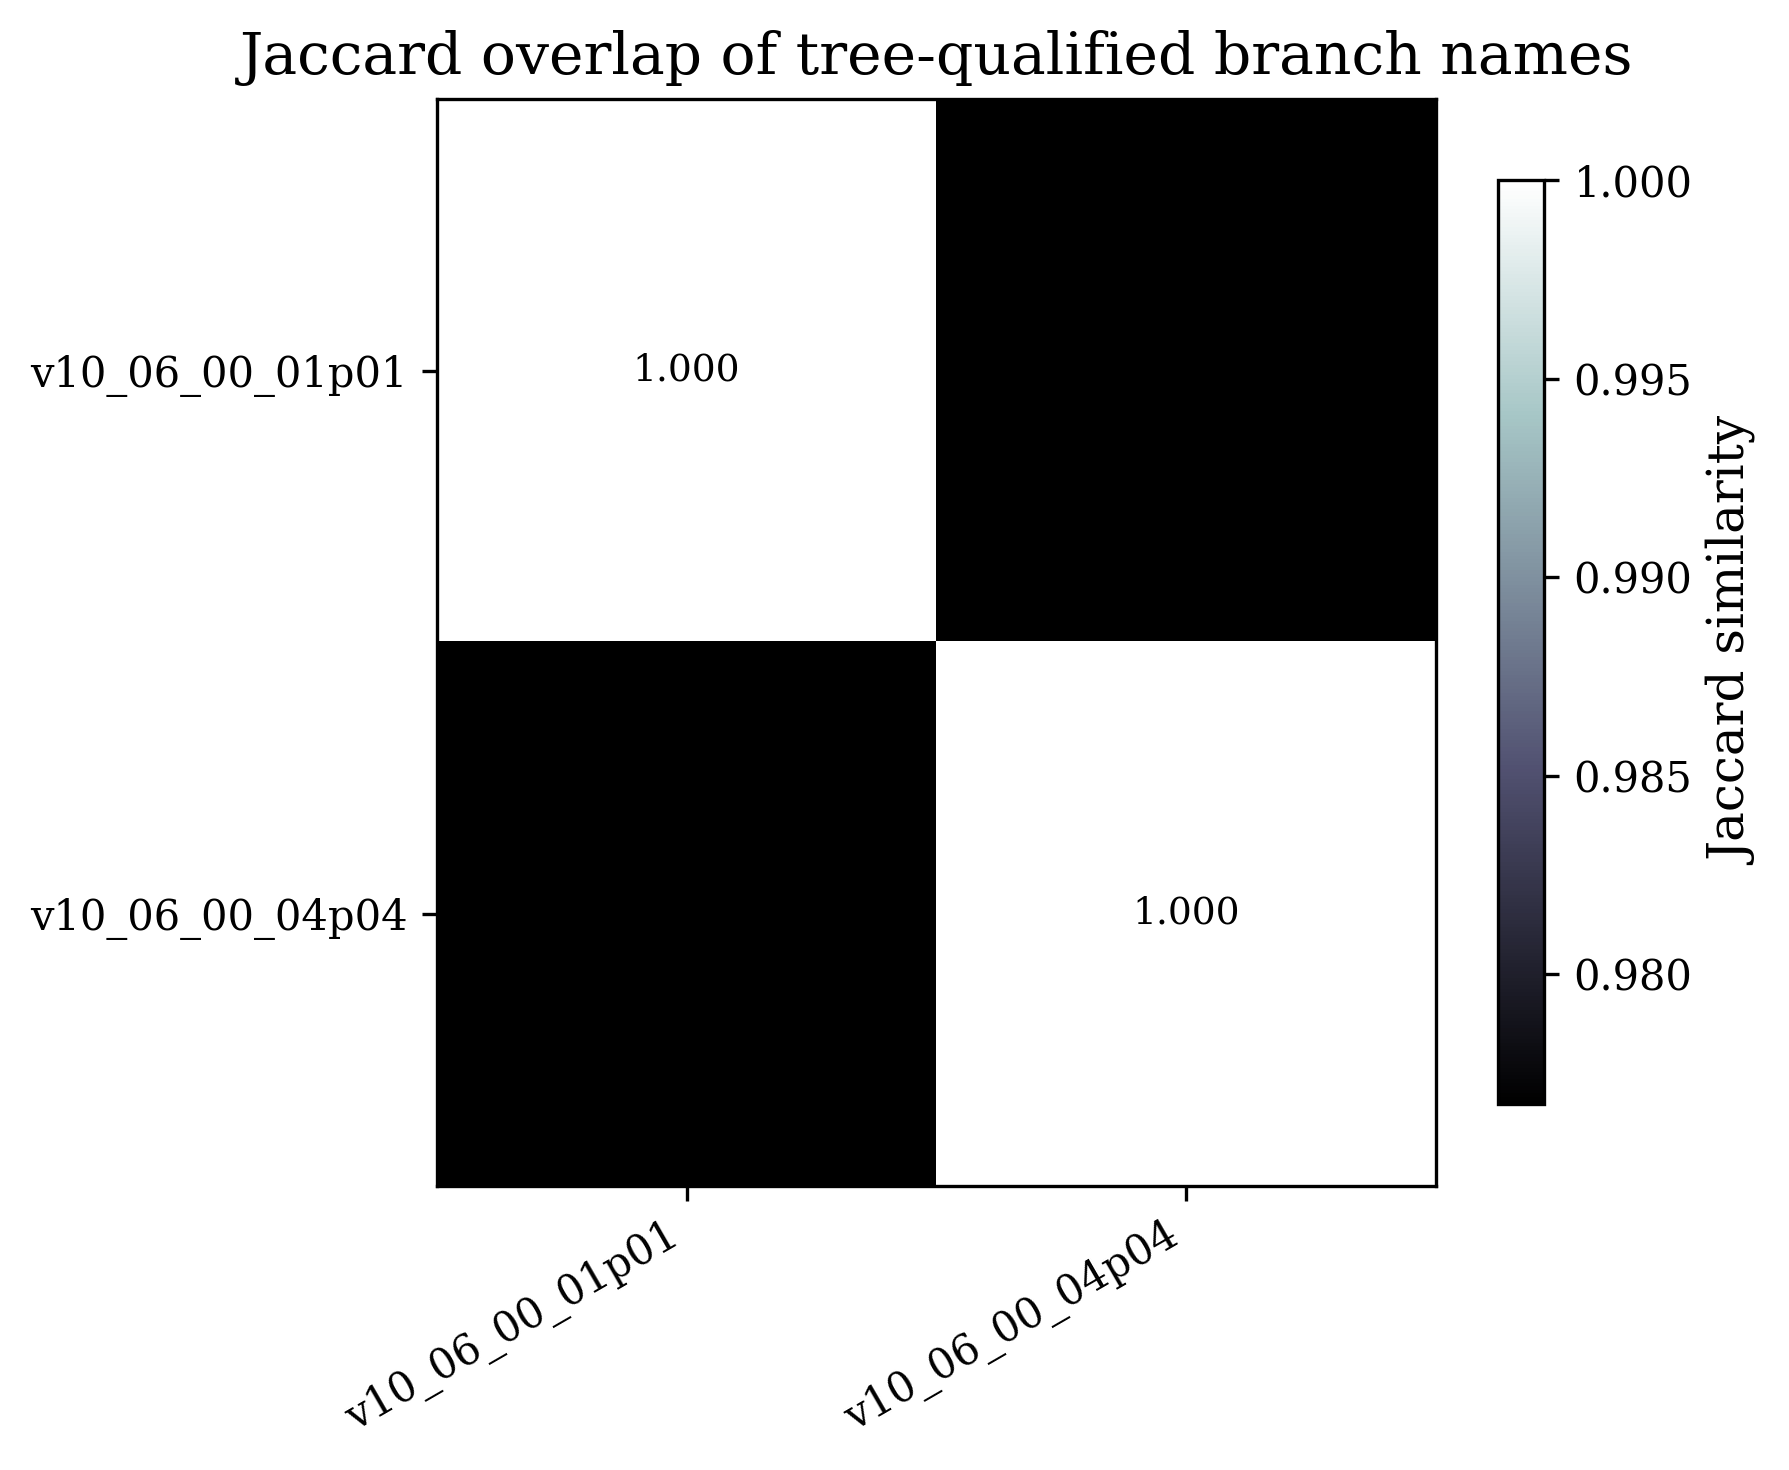

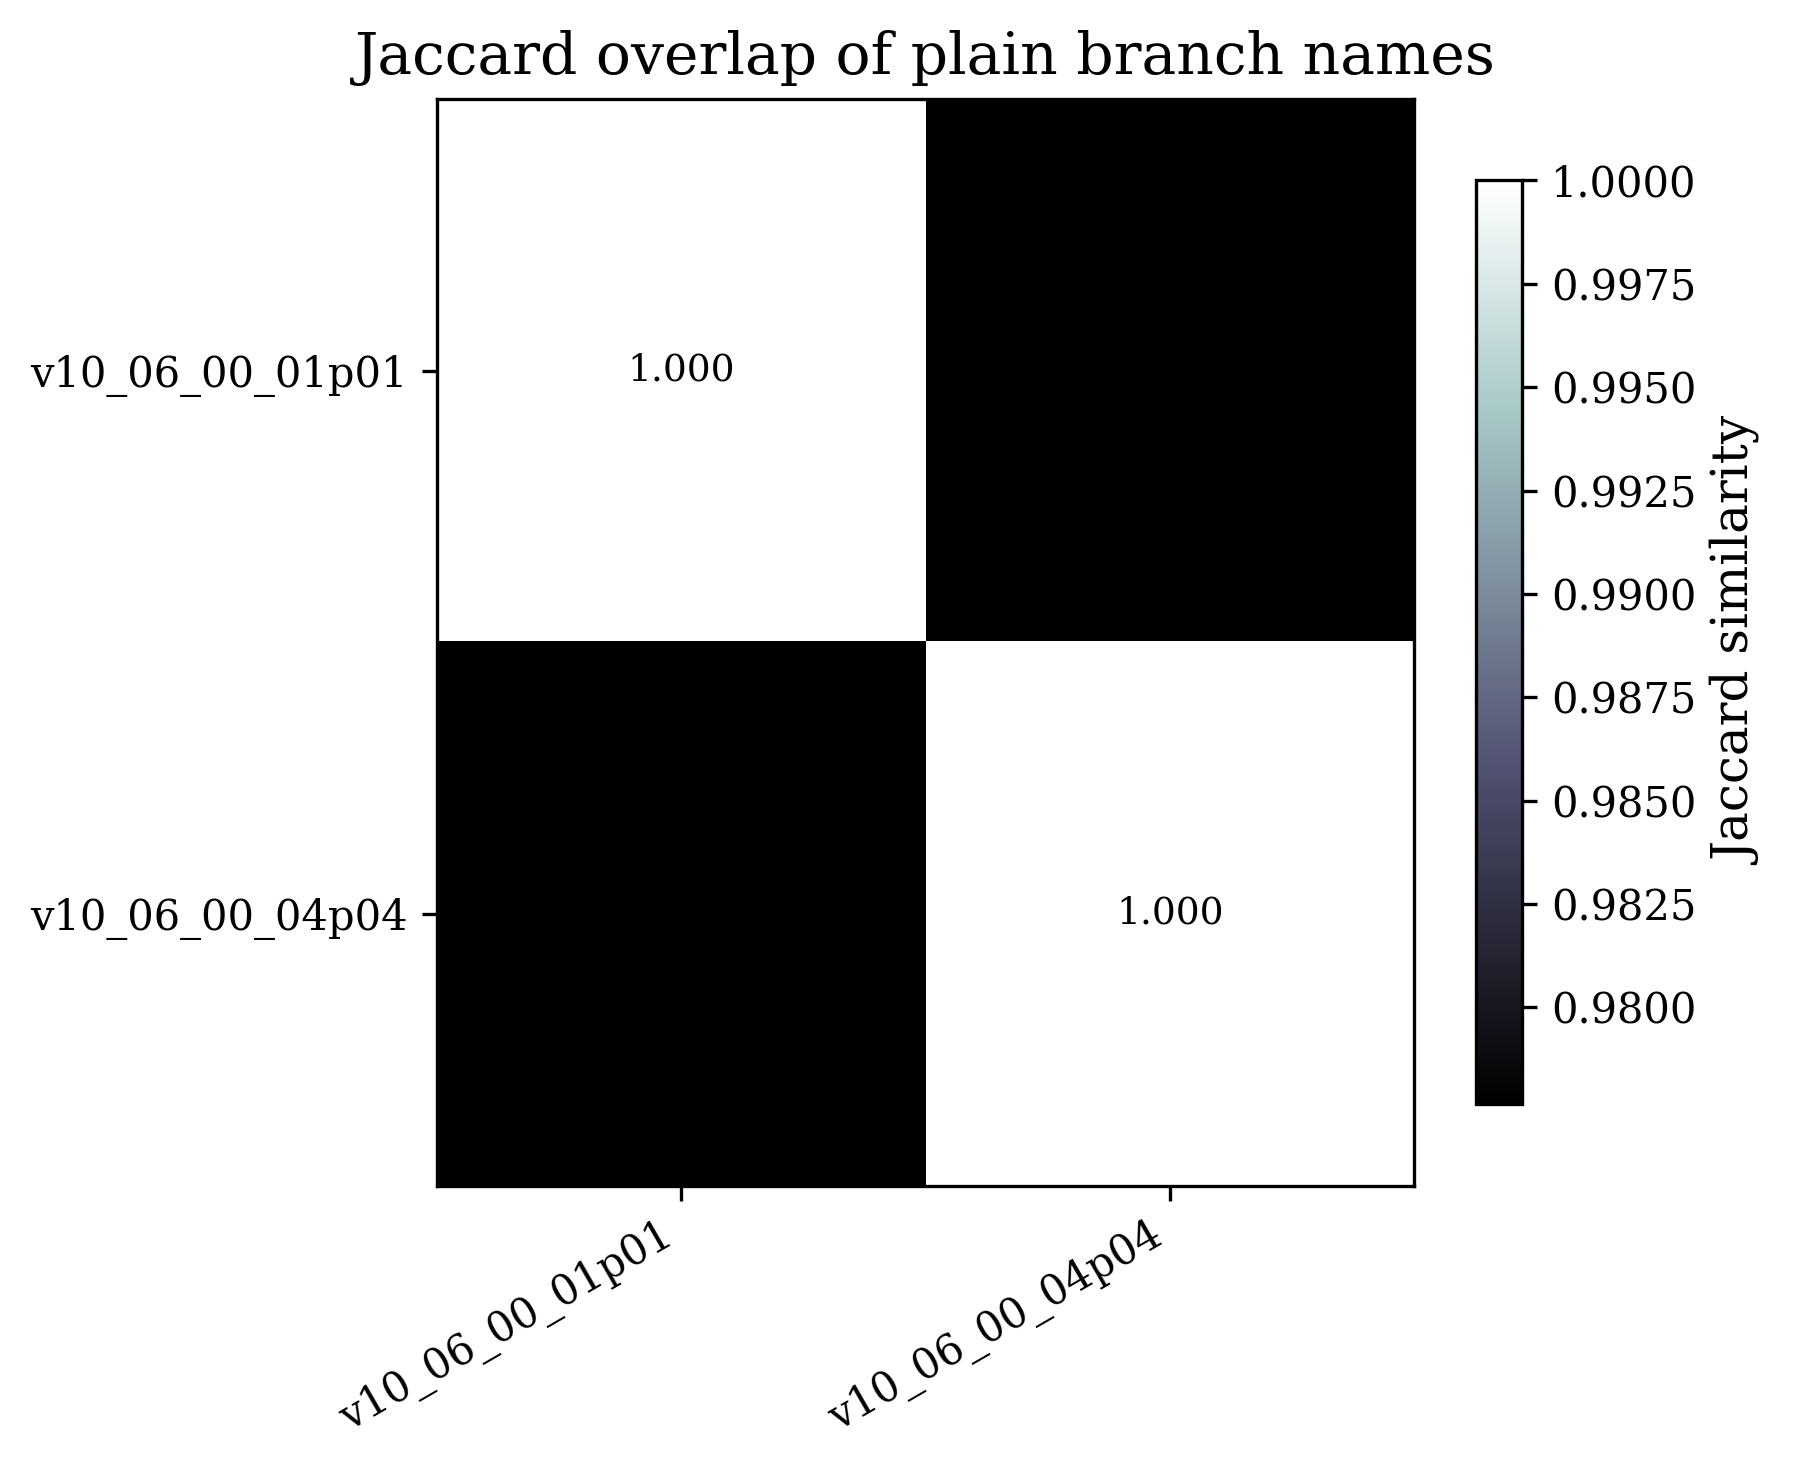

In [8]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "STIXGeneral"],
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

def plot_heatmap(df, title, outfile):
    fig, ax = plt.subplots(figsize=(6, 5),dpi=300)

    im = ax.imshow(
        df.values,
        aspect="auto",
        cmap="bone"   
    )

    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(df.columns, rotation=30, ha="right")

    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)

    # Annotate values
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            ax.text(
                j, i,
                f"{df.iloc[i, j]:.3f}",
                ha="center",
                va="center",
                fontsize=9,
                color="white" if df.iloc[i, j] < 0.5 else "black"  
            )

    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Jaccard similarity", rotation=90)

    fig.tight_layout()
    fig.savefig(outfile, bbox_inches="tight", dpi=300)
    plt.show()

plot_heatmap(
    jaccard_tree_df,
    "Jaccard overlap of tree-qualified branch names",
    os.path.join(OUTDIR, "heatmap_jaccard_tree_qualified.png")
)

plot_heatmap(
    jaccard_plain_df,
    "Jaccard overlap of plain branch names",
    os.path.join(OUTDIR, "heatmap_jaccard_plain.png")
)

## Pairwise Differences

For each pair of versions, this writes:
- `*_common.csv` — branches present in both
- `*_only_in_A.csv` — branches only in the older version (potential removals or renames)
- `*_only_in_B.csv` — branches only in the newer version (new additions)
- `pairwise_summary.csv` — summary statistics

> **What to look for:** Anything in `only_in_A` that contains `NuGraph`, `ng_`, or a
> physics variable name signals a breaking change for downstream analysis macros.


In [9]:
pairwise_rows = []

for a, b in combinations(labels, 2):
    set_a = branch_inventory[a]
    set_b = branch_inventory[b]

    common = sorted(set_a & set_b)
    only_a = sorted(set_a - set_b)
    only_b = sorted(set_b - set_a)

    metrics = similarity_metrics(set_a, set_b)
    pairwise_rows.append({
        "A": a,
        "B": b,
        **metrics
    })

    pair_tag = f"{safe_name(a)}__vs__{safe_name(b)}"

    pd.DataFrame({"branch": common}).to_csv(
        os.path.join(OUTDIR, f"{pair_tag}_common.csv"), index=False
    )
    pd.DataFrame({"branch": only_a}).to_csv(
        os.path.join(OUTDIR, f"{pair_tag}_only_in_{safe_name(a)}.csv"), index=False
    )
    pd.DataFrame({"branch": only_b}).to_csv(
        os.path.join(OUTDIR, f"{pair_tag}_only_in_{safe_name(b)}.csv"), index=False
    )

    save_list_txt(common, os.path.join(OUTDIR, f"{pair_tag}_common.txt"))
    save_list_txt(only_a, os.path.join(OUTDIR, f"{pair_tag}_only_in_{safe_name(a)}.txt"))
    save_list_txt(only_b, os.path.join(OUTDIR, f"{pair_tag}_only_in_{safe_name(b)}.txt"))

pairwise_summary_df = pd.DataFrame(pairwise_rows).sort_values(["A", "B"])
pairwise_summary_df.to_csv(os.path.join(OUTDIR, "pairwise_summary.csv"), index=False)

pairwise_summary_df

,A,B,n_A,n_B,n_common,n_only_A,n_only_B,frac_A_in_B,frac_B_in_A,jaccard
0,v10_06_00_01p01,v10_06_00_04p04,2057,2106,2057,0,49,1.0,0.976733,0.976733


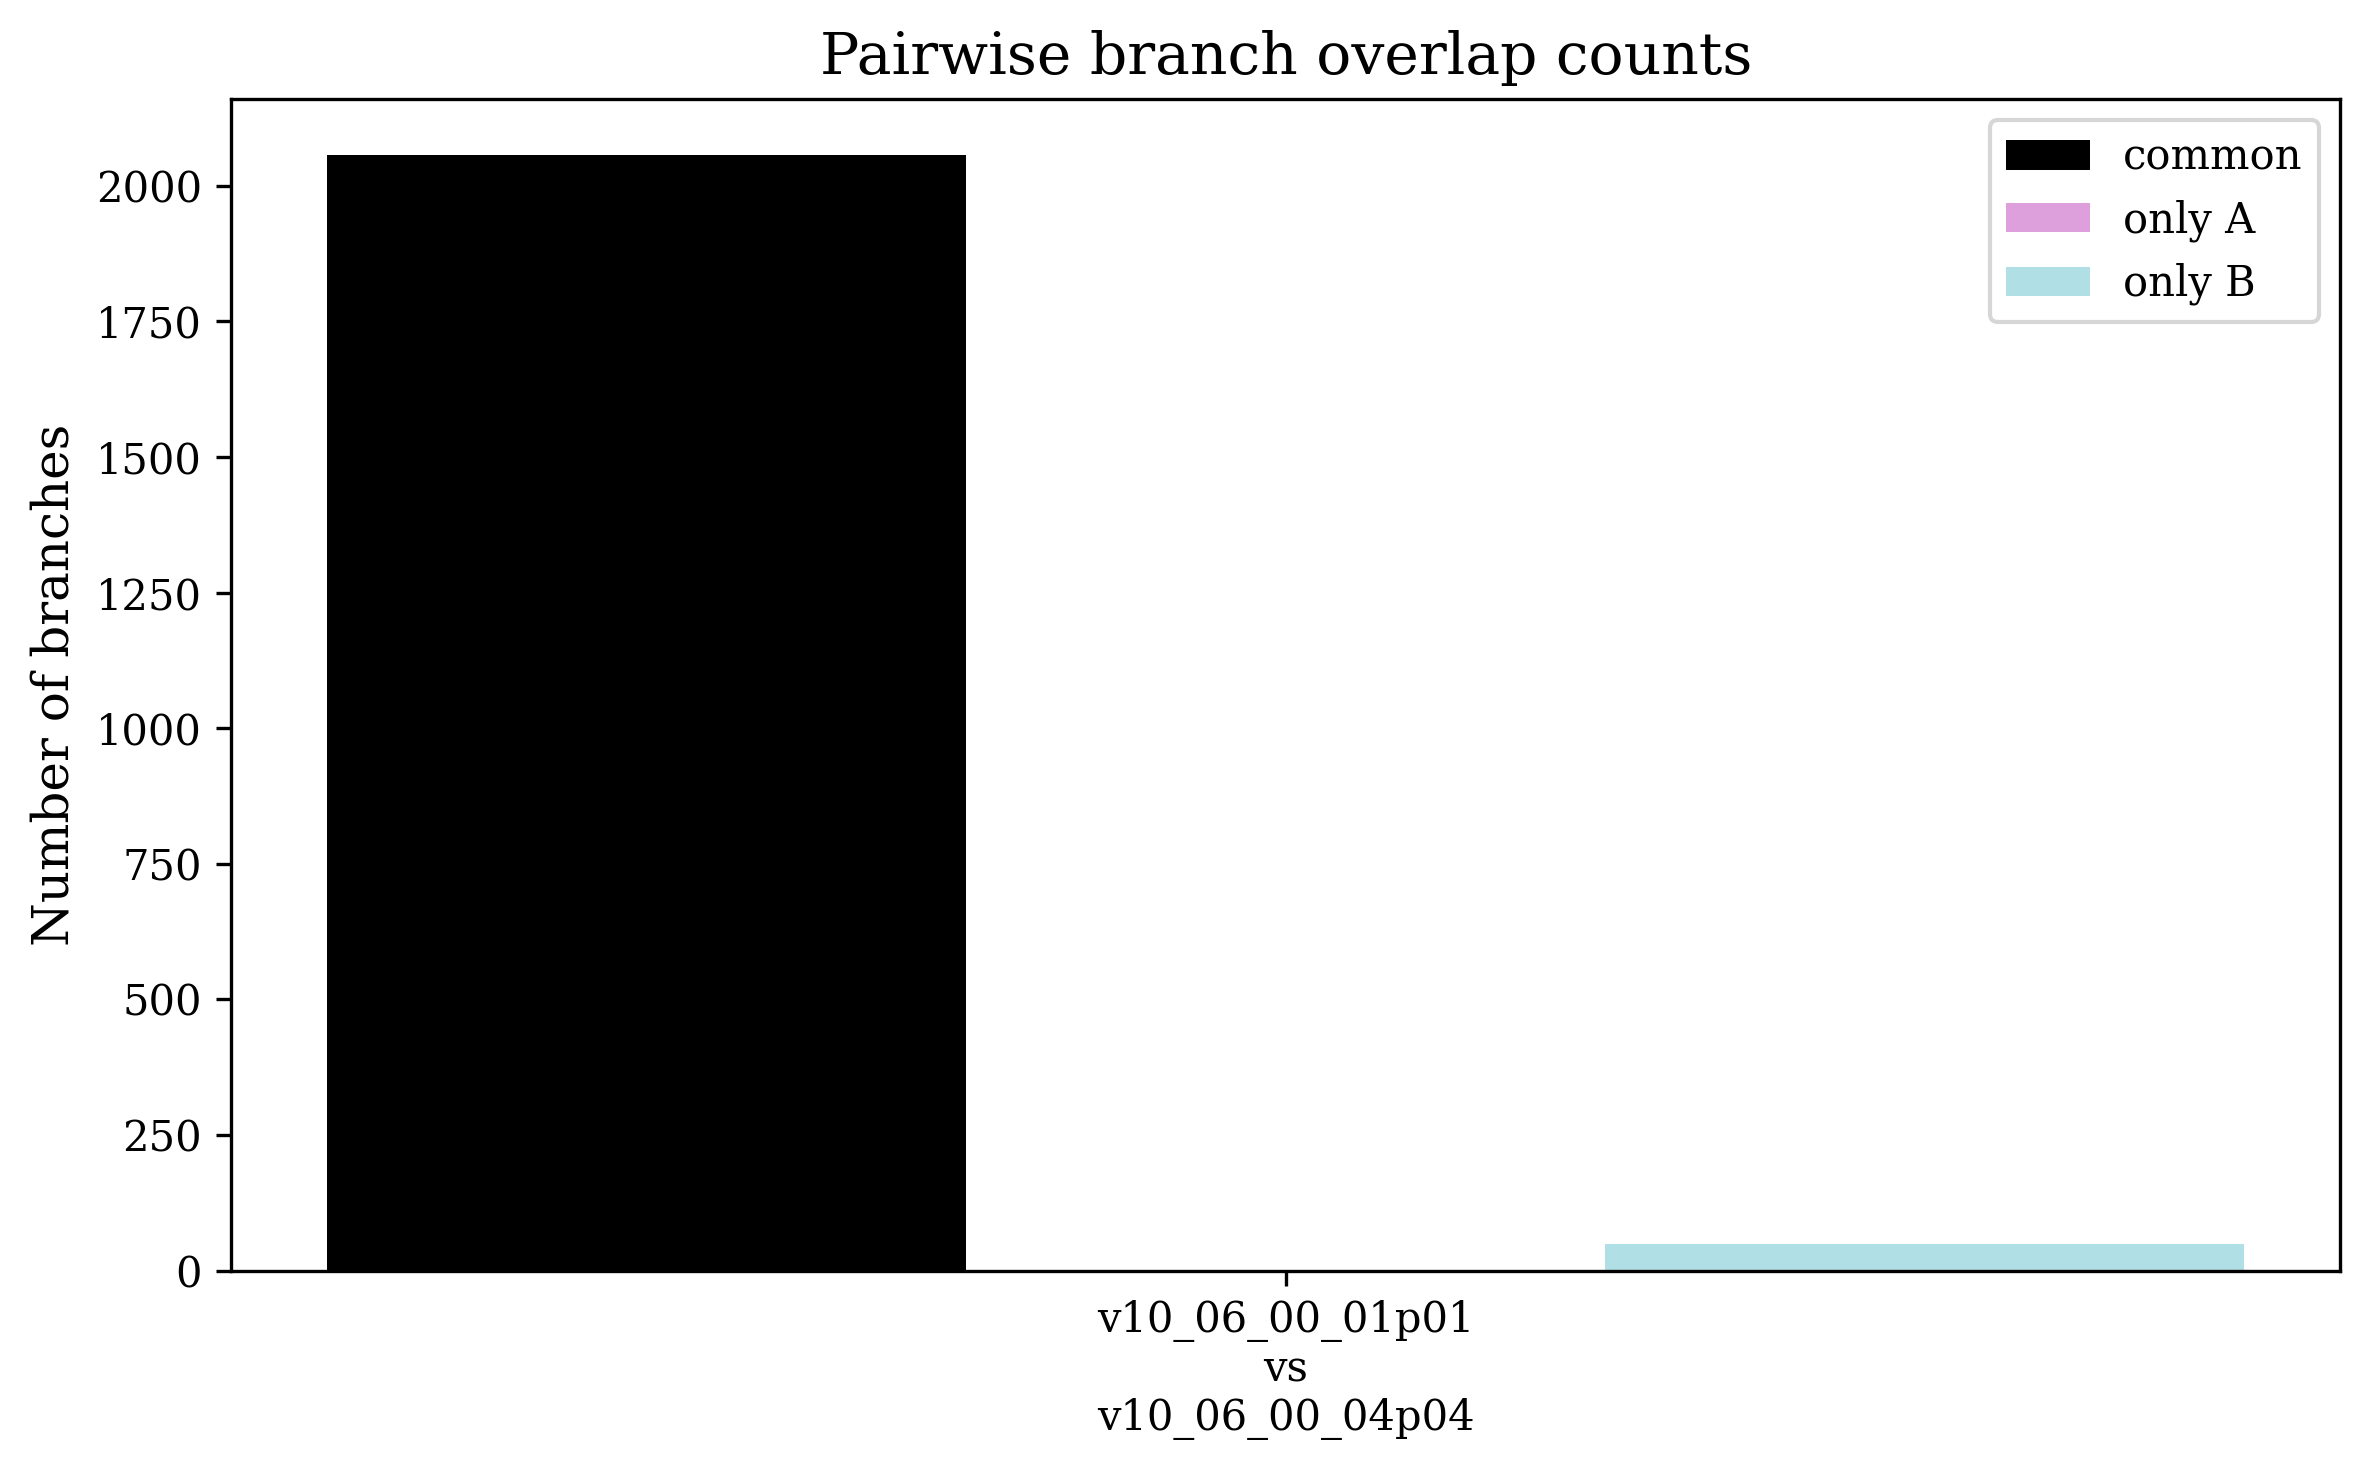

In [10]:
plot_df = pairwise_summary_df.copy()
plot_df["pair"] = plot_df["A"] + "\nvs\n" + plot_df["B"]

x = np.arange(len(plot_df))
w = 0.25

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
ax.bar(x - w, plot_df["n_common"], width=w, label="common", color='black')
ax.bar(x, plot_df["n_only_A"], width=w, label="only A", color='plum')
ax.bar(x + w, plot_df["n_only_B"], width=w, label="only B", color='powderblue')
ax.set_xticks(x)
ax.set_xticklabels(plot_df["pair"])
ax.set_ylabel("Number of branches")
ax.set_title("Pairwise branch overlap counts")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, "pairwise_overlap_counts.png"), bbox_inches="tight")
plt.show()

## Presence / Absence Matrix

A matrix showing which branches are present in which versions.
Useful for identifying:
- Branches present in **all** versions (stable)
- Branches **unique to one version** (new additions or removals)
- Branches shared only by a **subset** of versions (partially introduced)


In [11]:
all_branches = sorted(set().union(*branch_inventory.values()))

presence_df = pd.DataFrame({"branch": all_branches})
for label in labels:
    s = branch_inventory[label]
    presence_df[label] = presence_df["branch"].isin(s).astype(int)

presence_df["n_files_present"] = presence_df[labels].sum(axis=1)
presence_df = presence_df.sort_values(["n_files_present", "branch"], ascending=[False, True])

presence_df.to_csv(os.path.join(OUTDIR, "branch_presence_matrix.csv"), index=False)
presence_df.head(50)

,branch,v10_06_00_01p01,v10_06_00_04p04,n_files_present
29,metadata/metatree/key,1,1,2
30,metadata/metatree/value,1,1,2
31,recTree/rec.crt_hits..length,1,1,2
32,recTree/rec.crt_hits.pe,1,1,2
33,recTree/rec.crt_hits.plane,1,1,2
34,recTree/rec.crt_hits.position.x,1,1,2
35,recTree/rec.crt_hits.position.y,1,1,2
36,recTree/rec.crt_hits.position.z,1,1,2
37,recTree/rec.crt_hits.position_err.x,1,1,2
38,recTree/rec.crt_hits.position_err.y,1,1,2


In [12]:
for label in labels:
    unique_df = presence_df[(presence_df[label] == 1) & (presence_df["n_files_present"] == 1)]
    print(f"\n{label}: {len(unique_df)} branches unique to this file")
    display(unique_df.head(20))


v10_06_00_01p01: 0 branches unique to this file


,branch,v10_06_00_01p01,v10_06_00_04p04,n_files_present



v10_06_00_04p04: 49 branches unique to this file


,branch,v10_06_00_01p01,v10_06_00_04p04,n_files_present
0,GenieEvtRecTree/GENIEEntry,0,1,1
1,GenieEvtRecTree/GenieEvtRec.EvtDXSec,0,1,1
2,GenieEvtRecTree/GenieEvtRec.EvtKPS,0,1,1
3,GenieEvtRecTree/GenieEvtRec.EvtNum,0,1,1
4,GenieEvtRecTree/GenieEvtRec.EvtProb,0,1,1
5,GenieEvtRecTree/GenieEvtRec.EvtVtx,0,1,1
6,GenieEvtRecTree/GenieEvtRec.EvtWght,0,1,1
7,GenieEvtRecTree/GenieEvtRec.EvtXSec,0,1,1
8,GenieEvtRecTree/GenieEvtRec.StdHepFd,0,1,1
9,GenieEvtRecTree/GenieEvtRec.StdHepFm,0,1,1


## Tree-Level Comparison

Sometimes the global branch count difference is dominated by one TTree
(e.g. `recTree` vs `nuTree`). This section compares matching tree names pairwise
to show where the differences are concentrated.


In [13]:
tree_pair_rows = []

for a, b in combinations(labels, 2):
    trees_a = tree_inventory[a]
    trees_b = tree_inventory[b]
    common_trees = sorted(set(trees_a) & set(trees_b))

    for tree_name in common_trees:
        set_a = set(trees_a[tree_name])
        set_b = set(trees_b[tree_name])
        metrics = similarity_metrics(set_a, set_b)
        tree_pair_rows.append({
            "A": a,
            "B": b,
            "tree_name": tree_name,
            **metrics
        })

tree_pair_df = pd.DataFrame(tree_pair_rows).sort_values(["A", "B", "tree_name"])
tree_pair_df.to_csv(os.path.join(OUTDIR, "tree_pairwise_summary.csv"), index=False)

tree_pair_df.head(100)

,A,B,tree_name,n_A,n_B,n_common,n_only_A,n_only_B,frac_A_in_B,frac_B_in_A,jaccard
0,v10_06_00_01p01,v10_06_00_04p04,metadata/metatree,2,2,2,0,0,1.0,1.000000,1.000000
1,v10_06_00_01p01,v10_06_00_04p04,recTree,2055,2075,2055,0,20,1.0,0.990361,0.990361


In [14]:
def first_token(branch_name):
    b = branch_name.split("/", 1)[-1]
    tok = re.split(r"[._]", b)[0]
    return tok

for a, b in combinations(labels, 2):
    only_a = sorted(branch_inventory[a] - branch_inventory[b])
    only_b = sorted(branch_inventory[b] - branch_inventory[a])

    prefix_a = pd.Series([first_token(x) for x in only_a], name="prefix").value_counts().rename_axis("prefix").reset_index(name="count")
    prefix_b = pd.Series([first_token(x) for x in only_b], name="prefix").value_counts().rename_axis("prefix").reset_index(name="count")

    tag = f"{safe_name(a)}__vs__{safe_name(b)}"
    prefix_a.to_csv(os.path.join(OUTDIR, f"{tag}_prefix_counts_only_in_{safe_name(a)}.csv"), index=False)
    prefix_b.to_csv(os.path.join(OUTDIR, f"{tag}_prefix_counts_only_in_{safe_name(b)}.csv"), index=False)

    print(f"\nTop prefixes only in {a} relative to {b}")
    display(prefix_a.head(20))
    print(f"Top prefixes only in {b} relative to {a}")
    display(prefix_b.head(20))


Top prefixes only in v10_06_00_01p01 relative to v10_06_00_04p04


,prefix,count


Top prefixes only in v10_06_00_04p04 relative to v10_06_00_01p01


,prefix,count
0,rec,20
1,GenieEvtRec,18
2,global/wgts/wgts,5
3,GENIEEntry,1
4,SourceFileHash,1
5,envtree/value,1
6,envtree/key,1
7,global/wgts,1
8,global,1


## Summary and Next Steps

Check the `caf_branch_comparison_outputs/` directory for all saved CSVs and plots.

**Suggested outputs to inspect first:**
- `pairwise_summary.csv` — high-level overlap statistics
- `*_only_in_A.csv` — branches removed or renamed in the new version
- `*_only_in_B.csv` — new branches added in the new version
- `branch_presence_matrix.csv` — full presence/absence table

**For a NuGraph port specifically:**
Filter `only_in_B` for `ng_` or `NuGraph` to see which NuGraph CAF variables
are new in the target version. These are the variables your `sbncode` port must produce.

Filter `only_in_A` for any NuGraph-related variable names to check whether any
were removed or renamed (requiring updates to analysis macros).
